In [200]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as mlines
from matplotlib.ticker import MaxNLocator
import itertools
import random
import math

from scipy.stats import bernoulli
from collections import Counter

from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix



## Problem 2

In [87]:
G = nx.karate_club_graph()

# structural features
clustering = nx.clustering(G)
betweenness = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)

# synthetic data
hi_weight = np.random.normal(loc=65, scale=15, size=len(G))
officer_weight = np.random.normal(loc=80, scale=30, size=len(G))

hi_height = np.random.normal(loc=150, scale=20, size=len(G))
officer_height = np.random.normal(loc=160, scale=40, size=len(G))


data = pd.DataFrame(
    index=G.nodes,
    data={
        "club": [G.nodes[node]["club"] for node in G.nodes],

        # structural features
        "degree": [G.degree[node] for node in G.nodes],
        "clustering": [clustering[node] for node in G.nodes],
        "betweenness": [betweenness[node] for node in G.nodes],
        "pagerank": [pagerank[node] for node in G.nodes],

        # synthetic data
        "height": [hi_height[node] if G.nodes[node]["club"] == "Mr. Hi" else officer_height[node] for node in G.nodes],
        "weight": [hi_weight[node] if G.nodes[node]["club"] == "Mr. Hi" else officer_weight[node] for node in G.nodes]
    }
)


In [125]:

def random_trees(R: int, X: pd.DataFrame, y: pd.Series) -> tuple[list[float], list[np.array]]:

    conf_mats = []
    scores = []

    for i in range(R):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

        rf = RandomForestClassifier(n_estimators=100)
        rf.fit(X_train, y_train)

        scores.append(rf.score(X_test, y_test))
        conf_mats.append(confusion_matrix(y_test, rf.predict(X_test)))

    return (scores, conf_mats)


[0.8571428571428571, 0.8571428571428571] [array([[1, 1],
       [0, 5]]), array([[1, 1],
       [0, 5]])]
[[ 2  2]
 [ 0 10]]


In [198]:
R = 5
X = data[["degree", "clustering", "betweenness", "pagerank", "height", "weight"]]
y = data["club"]


scores = []
y_pred = []
y_true = []
for i in range(R):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    rf = RandomForestClassifier(n_estimators=100)
    rf.fit(X_train, y_train)
    
    scores.append(rf.score(X_test, y_test))
    y_pred.append(rf.predict(X_test))
    y_true.append(y_test)

# print(f"F1: {f1_score(y_true, y_pred)}")
print(f"mean: {round(np.mean(scores), 3)}, std_dev: {round(np.std(scores), 3)}")

mean: 0.714, std_dev: 0.128


In [194]:
R = 50
X = data[["degree", "clustering", "height", "weight"]]
y = data["club"]


scores = []
for i in range(R):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    rf = RandomForestClassifier(n_estimators=100)
    rf.fit(X_train, y_train)

    scores.append(rf.score(X_test, y_test))

print(f"mean: {round(np.mean(scores), 3)}, std_dev: {round(np.std(scores), 3)}")

mean: 0.974, std_dev: 0.055


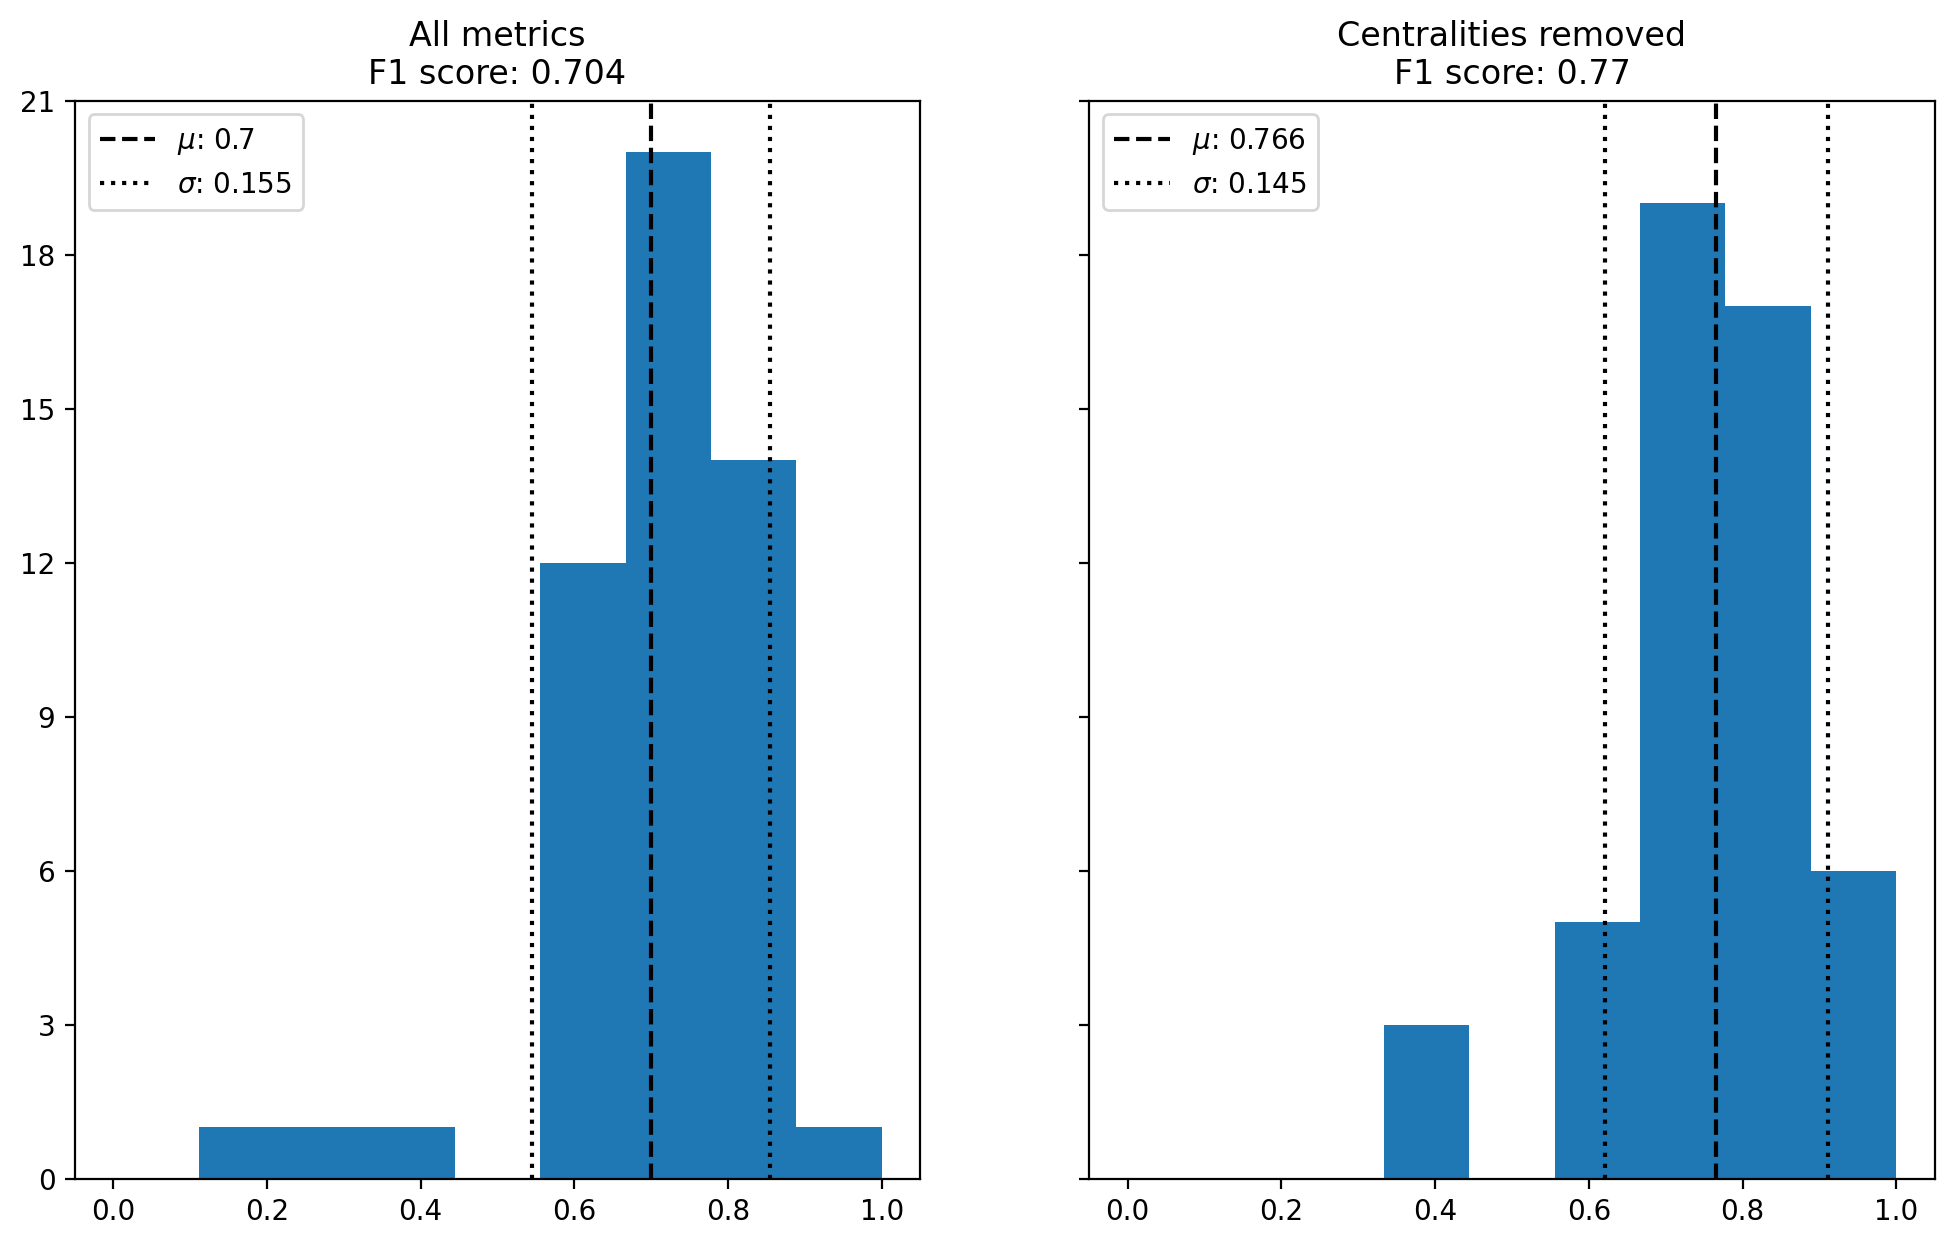

In [271]:
R = 50
X = data[["degree", "clustering", "betweenness", "pagerank", "height", "weight"]]
y = data["club"]

fig, ax = plt.subplots(1, 2, figsize=(12, 7), sharey=True, dpi=200)



scores = []
y_true = []
y_pred = []
for i in range(R):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    rf = RandomForestClassifier(n_estimators=75, random_state=i)
    rf.fit(X_train, y_train)

    scores.append(rf.score(X_test, y_test))
    y_true.append(y_test.values)
    y_pred.append(rf.predict(X_test))

y_true = list(itertools.chain(*y_true))
y_pred = list(itertools.chain(*y_pred))

mean = np.mean(scores)
std_dev = np.std(scores)
f1 = f1_score(y_true, y_pred, pos_label="Mr. Hi")

ax[0].set_title(f"All metrics\nF1 score: {round(f1, 3)}")
ax[0].hist(scores, bins=9, range=(0, 1))
ax[0].yaxis.set_major_locator(MaxNLocator(integer=True))
ax[0].axvline(x=mean, color="black", linestyle="dashed", label=r"$\mu$" + f": {round(mean, 3)}")
ax[0].axvline(x=mean + std_dev, color="black", linestyle="dotted", label=r"$\sigma$"+f": {round(std_dev, 3)}")
ax[0].axvline(x=mean - std_dev, color="black", linestyle="dotted")

ax[0].legend()



X = data[["degree", "clustering", "height", "weight"]]
y = data["club"]

scores = []
y_true = []
y_pred = []
for i in range(R):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    rf = RandomForestClassifier(n_estimators=75, random_state=i)
    rf.fit(X_train, y_train)

    scores.append(rf.score(X_test, y_test))
    y_true.append(y_test.values)
    y_pred.append(rf.predict(X_test))


y_true = list(itertools.chain(*y_true))
y_pred = list(itertools.chain(*y_pred))

mean = np.mean(scores)
std_dev = np.std(scores)
f1 = f1_score(y_true, y_pred, pos_label="Mr. Hi")
ax[1].set_title(f"Centralities removed\nF1 score: {round(f1, 3)}")
ax[1].hist(scores, bins=9, range=(0, 1))
ax[1].axvline(x=mean, color="black", linestyle="dashed", label=r"$\mu$" + f": {round(mean, 3)}")
ax[1].axvline(x=mean + std_dev, color="black", linestyle="dotted", label=r"$\sigma$"+f": {round(std_dev, 3)}")
ax[1].axvline(x=mean - std_dev, color="black", linestyle="dotted")

ax[1].legend()

plt.savefig("figures/2_f1_scores.png")

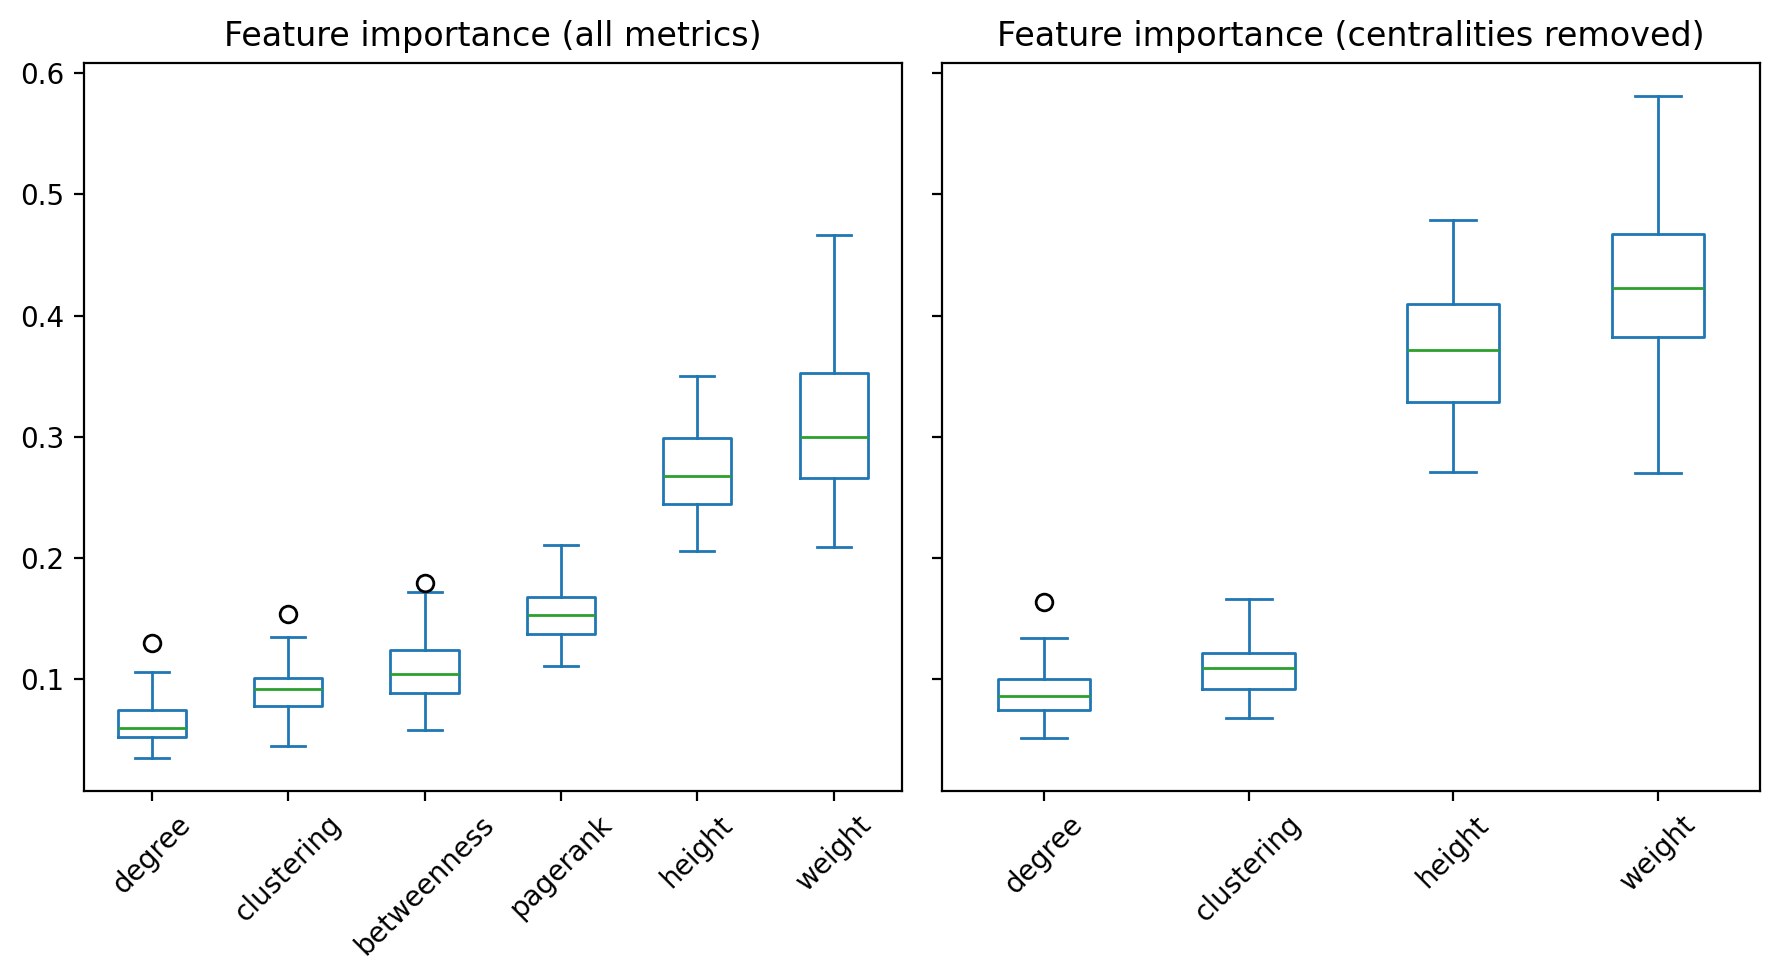

In [287]:
R = 50
X = data[["degree", "clustering", "betweenness", "pagerank", "height", "weight"]]
y = data["club"]

fig, ax = plt.subplots(1, 2, figsize=(9, 5), sharey=True, dpi=200)


importance = pd.DataFrame()

for i in range(R):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    rf = RandomForestClassifier(n_estimators=75, random_state=i)
    rf.fit(X_train, y_train)
    importance = pd.concat([importance, pd.DataFrame(data=rf.feature_importances_, index=X.columns).T])


ax[0].set_title(f"Feature importance (all metrics)")
importance.plot.box(ax=ax[0])
ax[0].tick_params("x", rotation=45)



X = data[["degree", "clustering", "height", "weight"]]
y = data["club"]


importance = pd.DataFrame()

for i in range(R):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    rf = RandomForestClassifier(n_estimators=75, random_state=i)
    rf.fit(X_train, y_train)
    importance = pd.concat([importance, pd.DataFrame(data=rf.feature_importances_, index=X.columns).T])


ax[1].set_title(f"Feature importance (centralities removed)")
importance.plot.box(ax=ax[1])
ax[1].tick_params("x", rotation=45)

plt.tight_layout()
plt.savefig("figures/2_feature_importance.png")

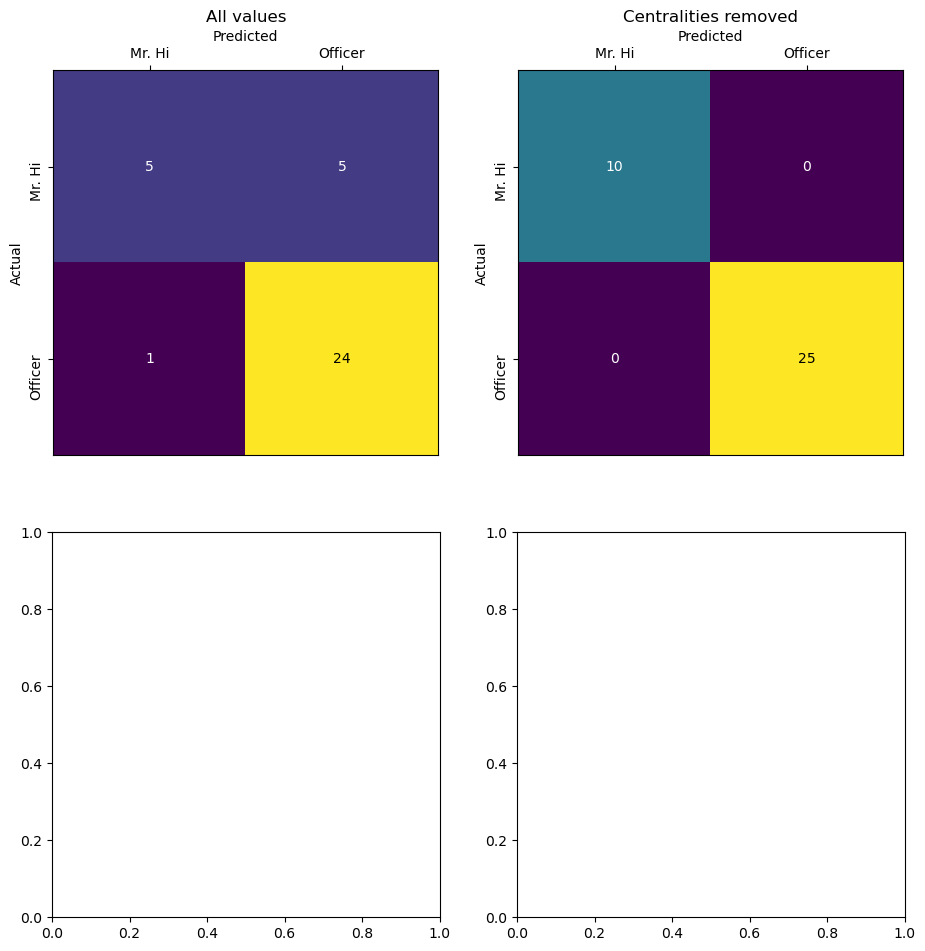

In [151]:

R = 5
Xs = [data[["degree", "clustering", "betweenness", "pagerank", "height", "weight"]],
      data[["degree", "clustering", "height", "weight"]]]
ys = [data["club"], data["club"]]

titles = ["All values", "Centralities removed"]

fig, ax = plt.subplots(2, 2, figsize=(11, 11))

# for i, (X, y) in enumerate(zip(Xs, ys)):

#     scores, conf_mats = random_trees(R, X, y)

#     conf_mat = np.add.reduce(conf_mats)

#     labels = y.unique()
#     ticks = range(len(labels))

#     ax[0, i].imshow(conf_mat)
#     ax[0 ,i].xaxis.set_ticks_position("top")
#     ax[0 ,i].xaxis.set_label_position("top")
#     ax[0 ,i].set_xticks(ticks, labels)
#     ax[0 ,i].set_yticks(ticks, labels, rotation=90)
#     ax[0 ,i].set_ylabel("Actual")
#     ax[0 ,i].set_xlabel("Predicted")
#     ax[0 ,i].set_title(titles[i])

#     for ii, jj in itertools.product(ticks, ticks):
#         if conf_mat[ii, jj] > 0.5 * np.max(conf_mat):
#             color = "black"
#         else:
#             color = "white"

#         text = ax[0, i].text(jj, ii, int(conf_mat[ii, jj]), ha="center", va="center", color=color)


    

plt.show()

## Problem 3

$p_{i, j} = \sigma ( \alpha - \beta d_{i, j} )$

$\sigma(z) = \frac{1}{1 + e^{-z}}$

In [ ]:
def geo_prob(alpha: float, beta: float, distance: float) -> float:
    """
    Probability function for random_geometric_graph():

        1 / (1 + exp{(beta * dist) - alpha})

    Parameters
    ----------
    alpha: float
    beta: float
    dist: float
        Distance between i and j

    Returns
    -------
    p: float
        Probability of edge
    """
    def sigma(z: float) -> float:
        return 1 / (1 + np.exp(-z))

    return sigma(alpha - (beta * distance))


def random_geometric_graph(n: int, alpha: float, beta:float) -> nx.Graph:
    """
    Creates a random geometric graph with probability of an edge being created given by:
    
        p_ij = 1 / (1 + exp{(beta * d_ij) - alpha})

    where d_ij is the Euclidean distance between nodes i and j.

    Parameters
    ----------
    n: int
        Number of nodes in the graph to be created
    alpha: float
        parameter
    beta: float
        parameter
    
    Returns
    -------
    G: nx.Graph
        Random geometric graph
    """

    G = nx.Graph()

    for i in range(n):
        G.add_node(i, loc=(np.random.rand(), np.random.rand()))

    for i, j in itertools.combinations(range(n), 2):
        i_loc = G.nodes[i]["loc"]
        j_loc = G.nodes[j]["loc"]

        dist = math.dist(i_loc, j_loc)

        p = geo_prob(alpha, beta, dist)

        if bernoulli.rvs(p):
            G.add_edge(i, j, dist=dist)

    return G


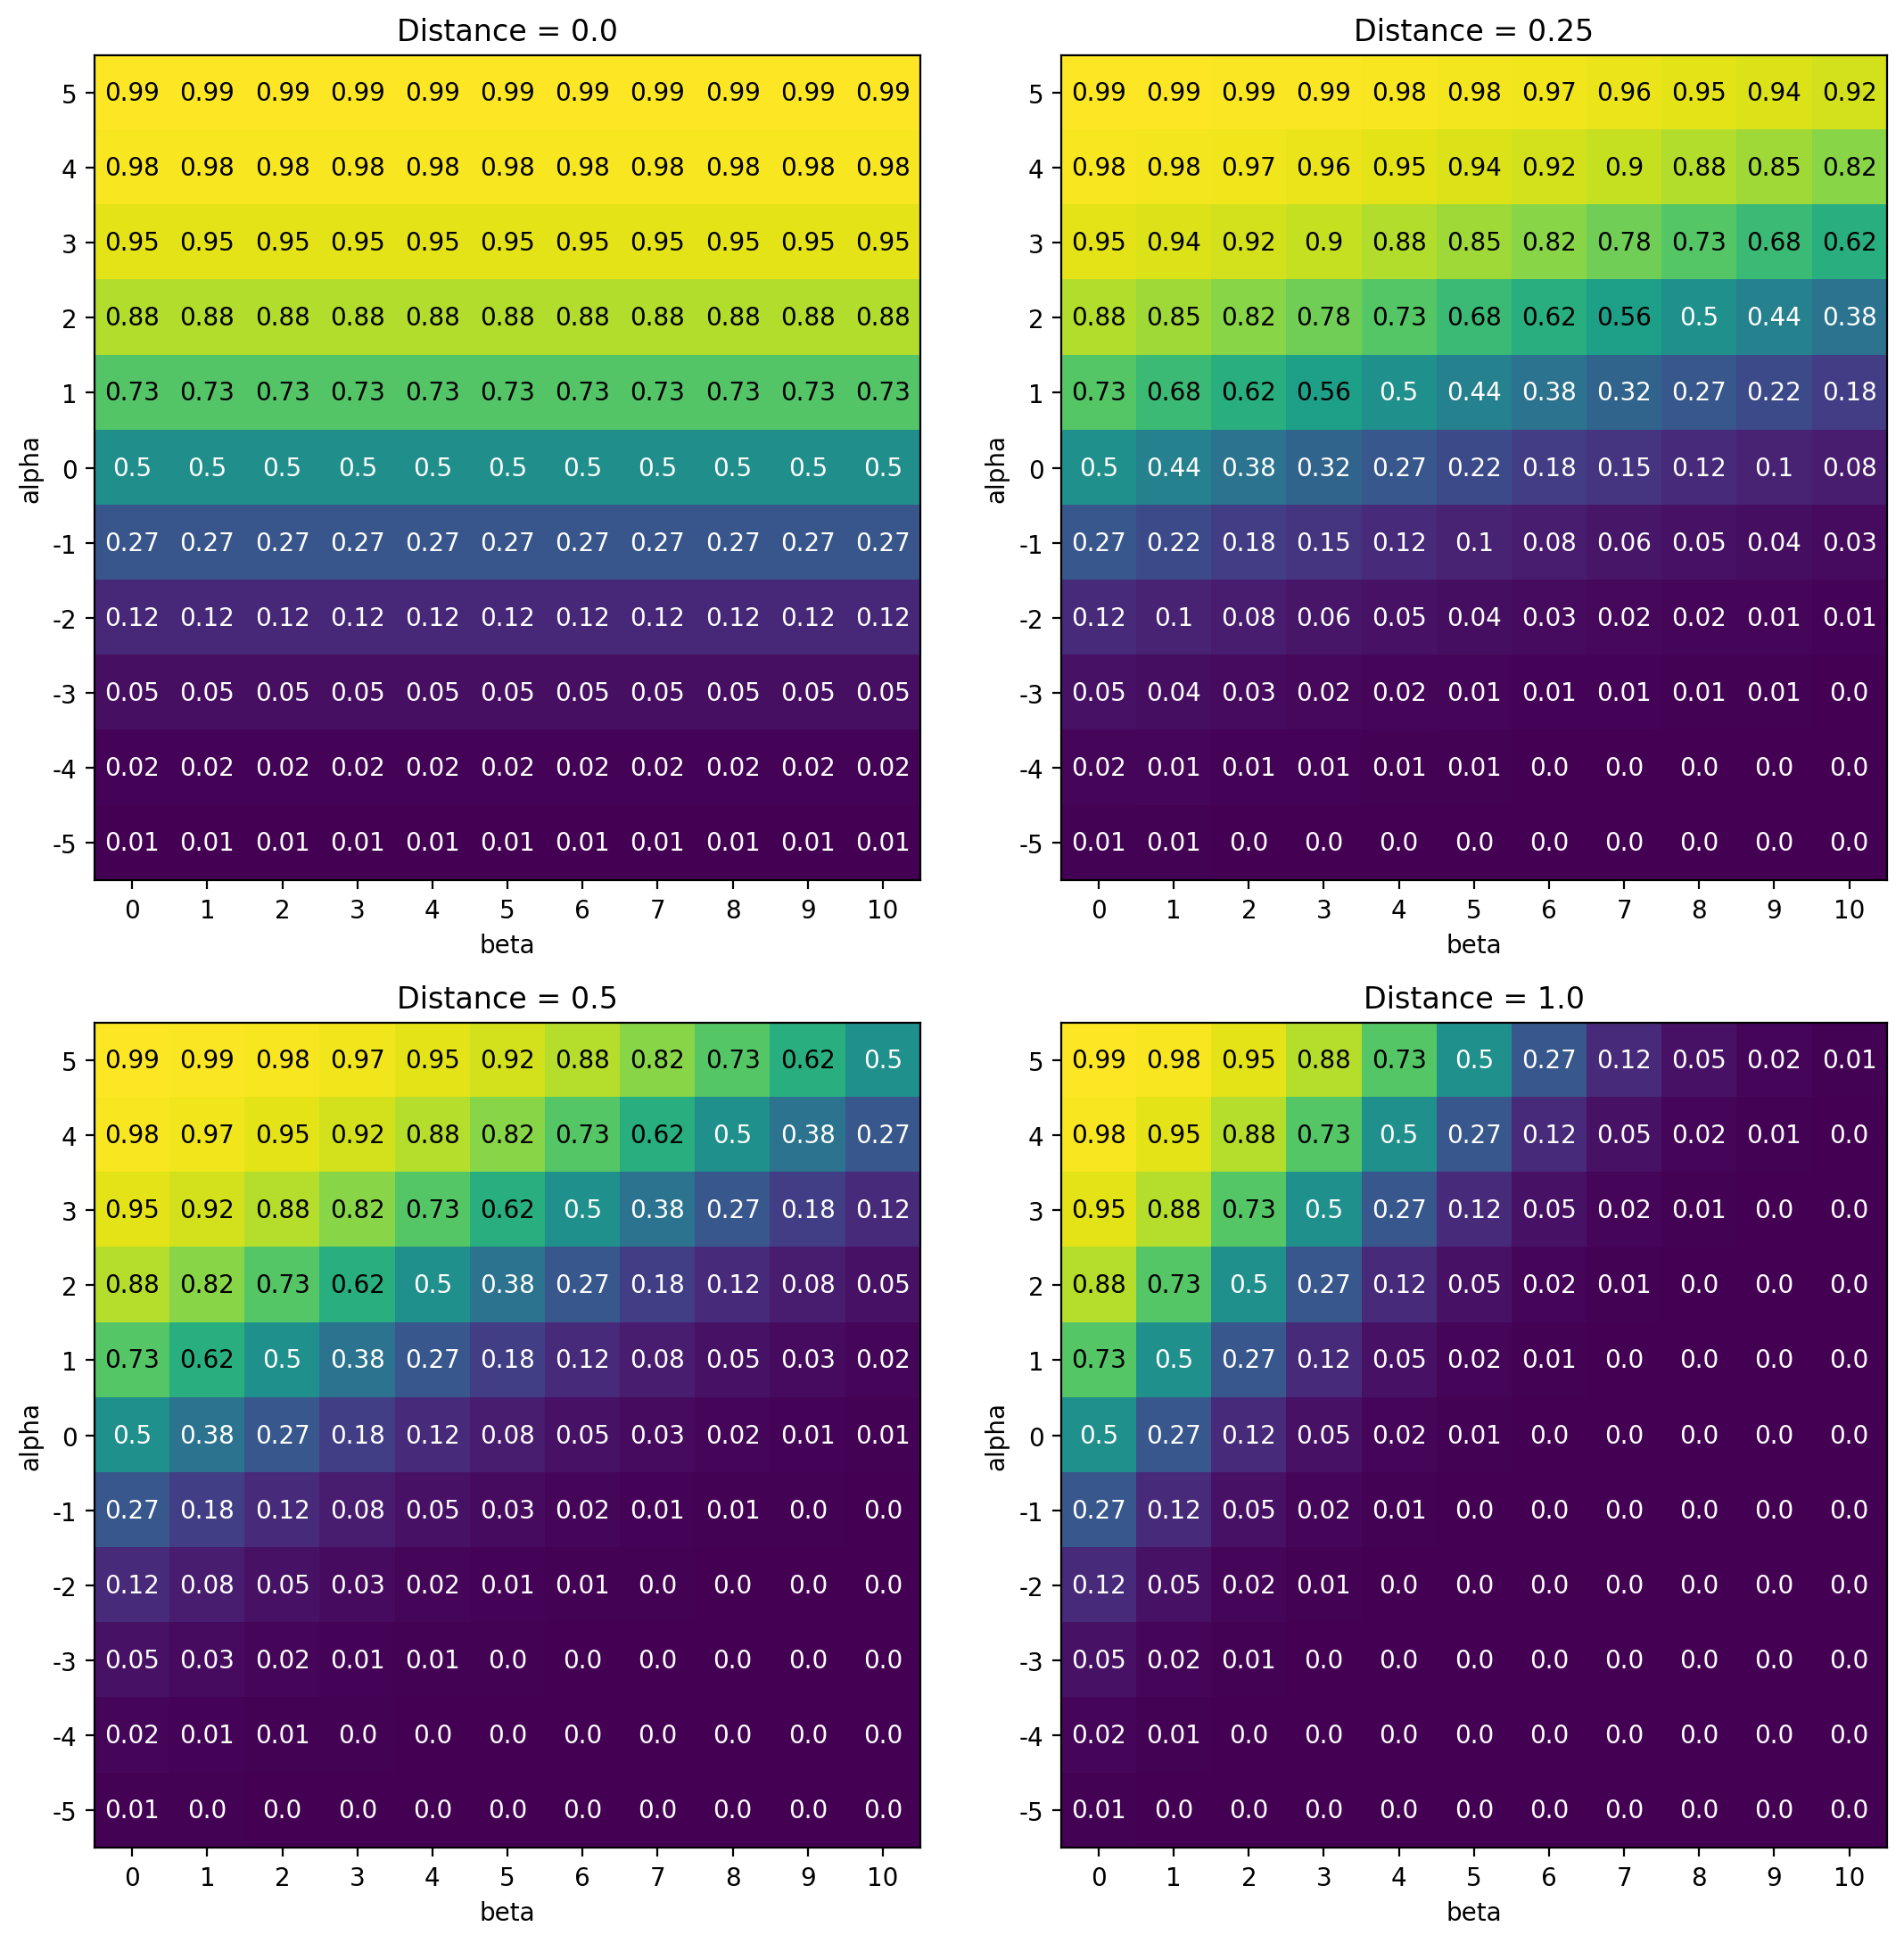

In [234]:
dists = [0.0, 0.25, 0.5, 1.0]

alphas = np.flip(np.arange(-5, 6, 1))
betas = np.arange(0, 11, 1)

rows = 2
cols = 2

fig, ax = plt.subplots(rows, cols, figsize=(11, 11), dpi=200)
idx = itertools.product(range(rows), range(cols))


for i, dist in zip(idx, dists):
    df = pd.DataFrame(index=alphas, columns=betas)

    for alpha, beta in itertools.product(alphas, betas):
        df.loc[alpha, beta] = geo_prob(alpha, beta, dist)

    a = df.to_numpy(dtype=float)

    ax[i].imshow(a)

    ax[i].set_yticks(range(len(alphas)))
    ax[i].set_yticklabels(alphas)
    ax[i].set_ylabel("alpha")

    ax[i].set_xticks(range(len(betas)))
    ax[i].set_xticklabels(betas)
    ax[i].set_xlabel("beta")

    ax[i].set_title(f"Distance = {dist}")

    for ii, jj in itertools.product(range(len(alphas)), range(len(betas))):
        if df.iloc[ii, jj] > 0.5:
            color = "black"
        else:
            color = "white"
        text = ax[i].text(jj, ii, round(df.iloc[ii, jj], 2), ha="center", va="center", color=color)

plt.tight_layout()
plt.savefig("figures/3_connection_probs.png")

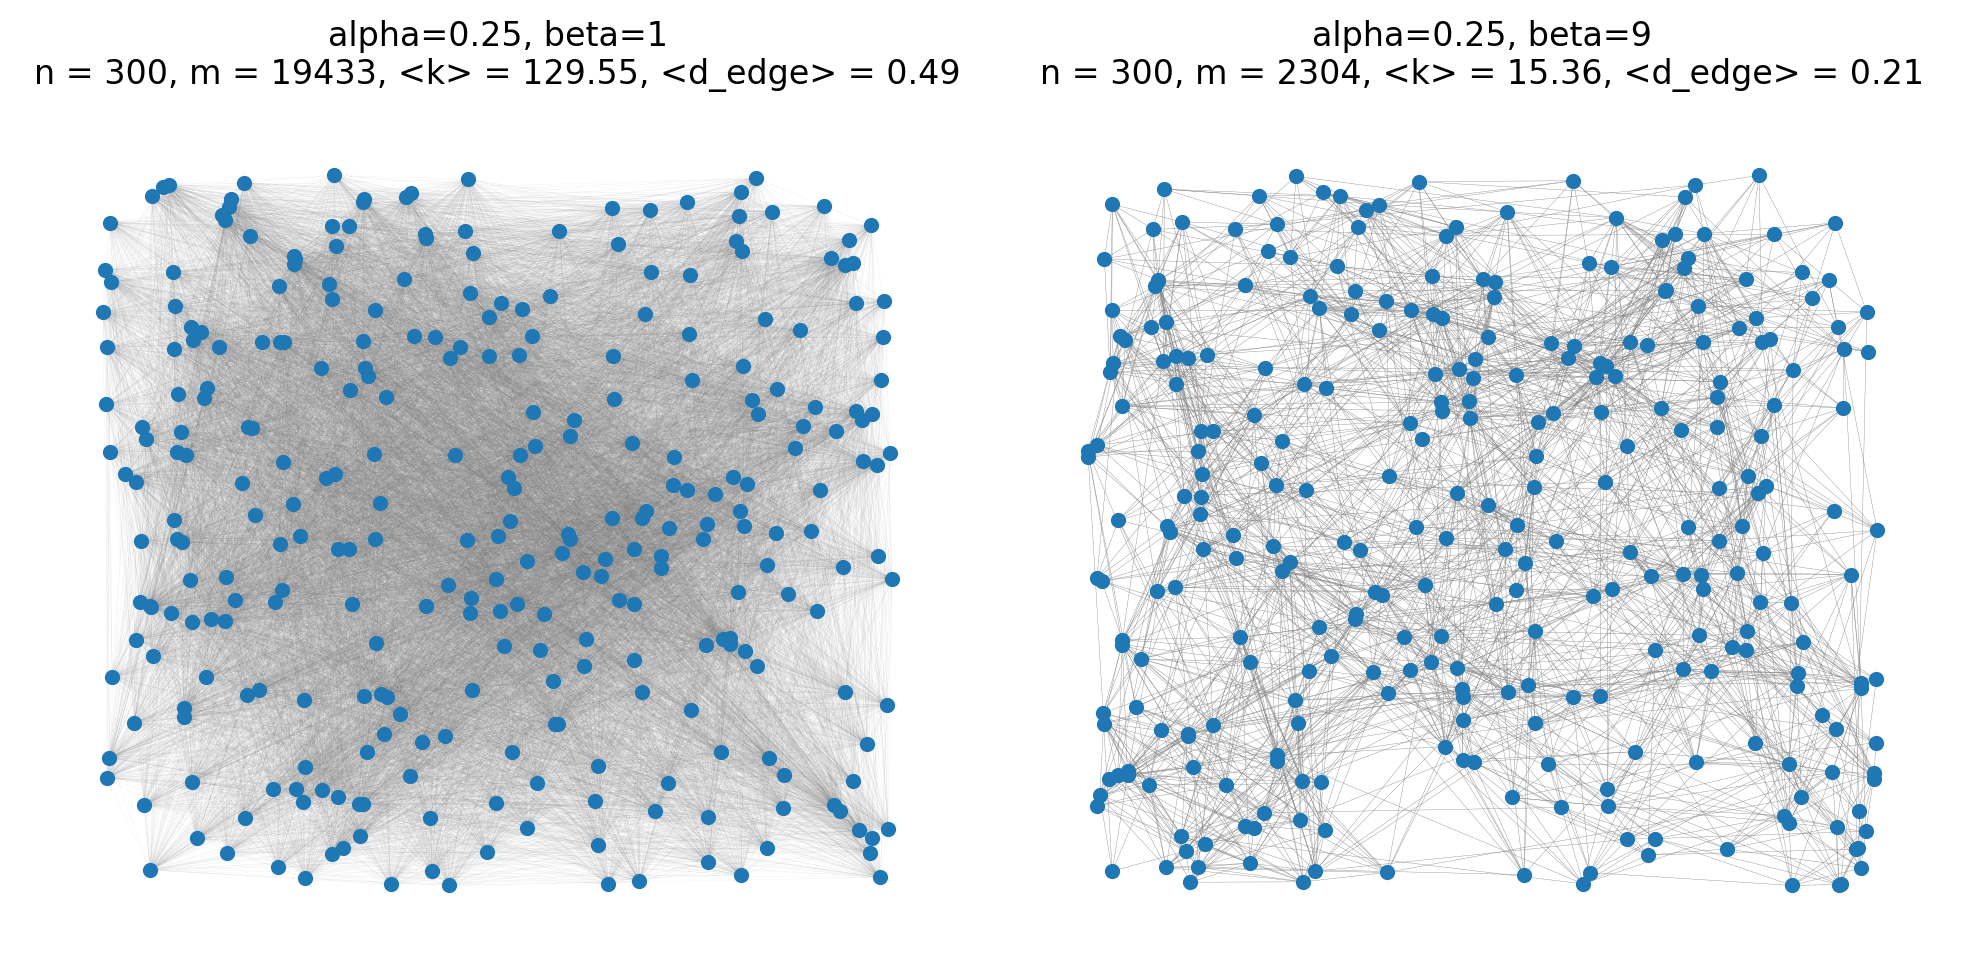

In [236]:
alpha = 0.25
betas = [1, 9]

n = 300

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200)

for i, beta in enumerate(betas):

    G = random_geometric_graph(n, alpha, beta)

    m = np.sum(np.triu(nx.to_numpy_array(G)))
    k = 2 * m / n

    avg_dist = sum([G.edges[edge]["dist"] for edge in G.edges]) / m

    pos = [G.nodes[node]["loc"] for node in G.nodes]

    ax[i].set_title(f"alpha={alpha}, beta={beta}\n" \
                    f"n = {int(n)}, m = {int(m)}, <k> = {round(k, 2)}, <d_edge> = {round(avg_dist, 2)}")
    nx.draw(G, pos=pos, node_size=20, width=(n/m), edge_color="grey", ax=ax[i])

plt.tight_layout()
plt.savefig("figures/3_random_geometric_graphs.png")